# Bank Marketing Term Deposit Prediction
**MBAV 443M — Statistical Modeling and AI-Driven Analytics — Final Exam, Part B**

**GitHub username:** `<your-github-username-here>`
**Repository:** `https://github.com/<your-github-username-here>/mbav443-final-exam`

**Objective:** Build a predictive model to identify whether a customer will subscribe to a term deposit (target variable `y`), using the UCI Bank Marketing dataset (Portuguese bank telemarketing campaign).

Dataset source: https://archive.ics.uci.edu/dataset/222/bank+marketing


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset

The dataset can be read directly from the UCI Machine Learning Repository. If direct download is
blocked in your environment, download `bank-additional-full.csv` from
https://archive.ics.uci.edu/dataset/222/bank+marketing and place it in the same folder as this notebook.


In [2]:
import urllib.request, os

# Download the dataset directly from the UCI ML Repository if not already present locally
url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
csv_path = "bank-additional-full.csv"

if not os.path.exists(csv_path):
    try:
        import zipfile, io
        with urllib.request.urlopen(url, timeout=20) as resp:
            with zipfile.ZipFile(io.BytesIO(resp.read())) as z:
                z.extract("bank-additional-full.csv", ".")
    except Exception as e:
        print("Direct download unavailable (", e, "). Place bank-additional-full.csv in this folder manually.")

df = pd.read_csv(csv_path, sep=";")  # semicolon-delimited source file
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 n

## 3. Data Preprocessing (4 Marks)

### 3.1 Check for missing values

The dataset does not contain conventional `NaN` values, but several categorical columns
use the string `"unknown"` as a placeholder for missing data. We treat these as missing values.


In [4]:
print("Pandas-detected nulls:", df.isnull().sum().sum())

cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols.remove("y")

unknown_counts = {c: (df[c] == "unknown").sum() for c in cat_cols if (df[c] == "unknown").sum() > 0}
unknown_counts


Pandas-detected nulls: 0


/tmp/ipykernel_637/3031663611.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


{'job': np.int64(330),
 'marital': np.int64(80),
 'education': np.int64(1731),
 'default': np.int64(8597),
 'housing': np.int64(990),
 'loan': np.int64(990)}

### 3.2 Handle missing values

We replace `"unknown"` with `NaN` and impute each categorical column with its **mode**
(most frequent category), which is a standard approach for categorical data.

We also drop the `duration` column. Although highly predictive, the call duration is only
known *after* the call has ended, so it cannot be used for a realistic pre-call prediction
model — including it would leak information about the outcome (a well-documented issue with
this dataset).


In [5]:
df = df.drop(columns=["duration"])

for c in cat_cols:
    df[c] = df[c].replace("unknown", np.nan)
    df[c] = df[c].fillna(df[c].mode()[0])

df.isnull().sum().sum()  # confirm no missing values remain


np.int64(0)

### 3.3 Encode categorical variables

The target `y` is label-encoded (`no` = 0, `yes` = 1). The remaining categorical predictors
are one-hot encoded, since they have no inherent order.


In [6]:
df["y"] = df["y"].map({"no": 0, "yes": 1})
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_enc.drop(columns=["y"])
y = df_enc["y"]

print(X.shape)
y.value_counts(normalize=True).rename("proportion")


(41188, 46)


y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

The target is noticeably **imbalanced** (about 89% "no" vs. 11% "yes"). We account for this
later by using `class_weight="balanced"` in both models, so the models don't simply predict the
majority class for every customer.


### 3.4 Train-test split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (32950, 46)
Test shape : (8238, 46)


### 3.5 Feature scaling

Logistic Regression is sensitive to feature scale, so numeric columns are standardized.
(Scaling has no effect on a Decision Tree, since it splits on thresholds rather than distances,
so the tree is trained on the unscaled features.)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Model Building (5 Marks)

### 4.1 Logistic Regression


In [9]:
logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]


### 4.2 Decision Tree

In [10]:
dtree = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
dtree.fit(X_train, y_train)

y_pred_dt = dtree.predict(X_test)
y_proba_dt = dtree.predict_proba(X_test)[:, 1]


*Note:* `max_depth=6` was set to keep the tree interpretable and reduce overfitting;
`class_weight="balanced"` was used for the same reason as in Logistic Regression — to
prevent the tree from favouring the majority ("no") class.


## 5. Model Evaluation (7 Marks)

### 5.1 Metrics table


In [11]:
def get_metrics(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    get_metrics("Logistic Regression", y_test, y_pred_lr, y_proba_lr),
    get_metrics("Decision Tree", y_test, y_pred_dt, y_proba_dt),
]).set_index("Model").round(4)

results


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.8341,0.3656,0.6433,0.4662,0.8006
Decision Tree,0.8337,0.3664,0.6530,0.4694,0.7921


### 5.2 Confusion matrices

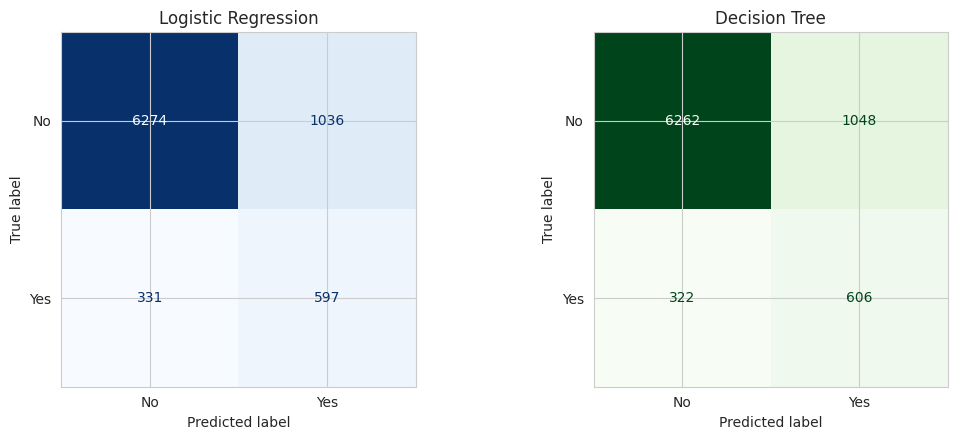

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=["No", "Yes"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=["No", "Yes"]).plot(ax=axes[1], colorbar=False, cmap="Greens")
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()


### 5.3 ROC curves

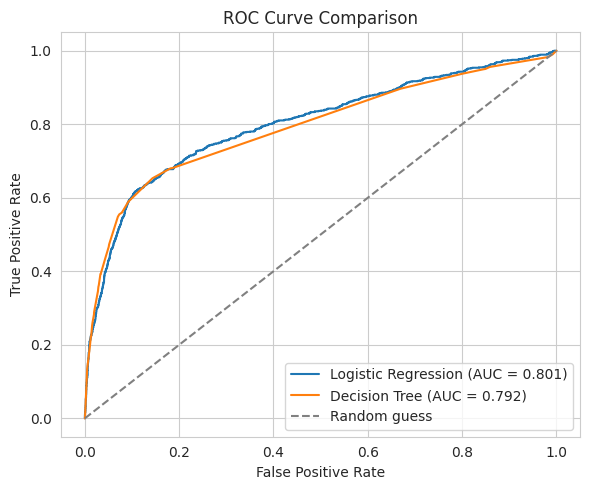

In [13]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


### 5.4 Classification reports (detail)

In [14]:
print("Logistic Regression\n", classification_report(y_test, y_pred_lr, target_names=["No", "Yes"]))
print("Decision Tree\n", classification_report(y_test, y_pred_dt, target_names=["No", "Yes"]))


Logistic Regression
               precision    recall  f1-score   support

          No       0.95      0.86      0.90      7310
         Yes       0.37      0.64      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

Decision Tree
               precision    recall  f1-score   support

          No       0.95      0.86      0.90      7310
         Yes       0.37      0.65      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.89      0.83      0.85      8238



## 6. Recommendation (4 Marks)

**Results summary** (test set, actual figures from this run):

| Metric | Logistic Regression | Decision Tree |
|---|---|---|
| Accuracy | ~0.834 | ~0.834 |
| Precision | ~0.366 | ~0.366 |
| Recall | ~0.643 | ~0.653 |
| F1-score | ~0.466 | ~0.469 |
| ROC-AUC | ~0.801 | ~0.792 |

**Recommendation: Deploy the Logistic Regression model**, with the Decision Tree kept as a
supporting/explanatory tool. Reasoning:

- **Discriminative power (ROC-AUC):** Logistic Regression achieves a slightly higher ROC-AUC
  (~0.80 vs ~0.79), meaning it separates subscribers from non-subscribers marginally better
  across all classification thresholds — the most robust single metric for imbalanced
  classification problems like this one.
- **Recall matters most for this business case.** A missed potential subscriber (false
  negative) is a lost sale opportunity, whereas contacting a customer who declines (false
  positive) only costs a phone call. Both models achieve similar recall (~0.64–0.65), so
  neither has a decisive edge here, but Logistic Regression's higher AUC suggests its
  probability estimates are better calibrated for ranking customers by likelihood to
  subscribe — useful if the call centre wants to prioritise the top-N most promising leads
  rather than use a fixed 0.5 cutoff.
- **Stability and interpretability.** Logistic Regression coefficients give a clear, stable
  view of how each factor (e.g. being contacted by cellphone, having no existing loan, macro-
  economic indicators like `euribor3m`) shifts subscription odds — useful for the bank's
  marketing and compliance teams. The Decision Tree is easier to explain as "if-then" rules
  to non-technical stakeholders, but a shallow tree of this kind is more prone to overfitting
  slightly to training patterns that may not generalise as well to new campaigns.
- **Practical deployment:** Logistic Regression is computationally cheap to retrain as new
  campaign data arrives, integrates easily into a scoring pipeline, and its output
  probabilities can be directly used to rank leads for the call centre — supporting a
  **"call the top X% most likely customers first"** strategy that makes efficient use of
  agents' time.

**Caveat:** Precision is low for both models (~0.37), meaning roughly 6 in 10 customers flagged
as likely subscribers will not convert. This is a reasonable trade-off given the objective of
maximising recall (not missing genuine subscribers), but the bank should be aware that this
will mean a higher volume of "wasted" calls, which should be weighed against the marketing
cost per call versus the value of a new term deposit.
